# Yelp Fraud Detection From Raw Data


In [23]:
%matplotlib inline

from pathlib import Path
import importlib.util
import urllib.request
import zipfile
import warnings

import numpy as np
import pandas as pd
from scipy import sparse
from scipy.io import loadmat
from scipy.sparse.csgraph import connected_components

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
warnings.filterwarnings("ignore", category=UserWarning)


In [24]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "tian_yelp_fraud_detection" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "FraudYelp"
MAT_PATH = DATA_DIR / "YelpChi.mat"
ZIP_PATH = DATA_DIR / "FraudYelp.zip"
FRAUD_YELP_URL = "https://data.dgl.ai/dataset/FraudYelp.zip"
FIGURE_DIR = PROJECT_ROOT / "figures" / "fraud_yelp"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 305
TRAIN_SIZE = 0.60
VAL_SIZE = 0.20

LABEL_NAMES = {0: "legitimate", 1: "fraud/spam"}
LABEL_COLORS = {0: "#2a9d8f", 1: "#e63946"}
RELATION_INFO = {
    "net_rur": "R-U-R: same user",
    "net_rtr": "R-T-R: same product and month",
    "net_rsr": "R-S-R: same product and rating",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Raw MAT file: {MAT_PATH}")


Project root: d:\Github\BitcoinTransactionClassification
Data directory: d:\Github\BitcoinTransactionClassification\data\FraudYelp
Raw MAT file: d:\Github\BitcoinTransactionClassification\data\FraudYelp\YelpChi.mat


## 1. Load The Raw YelpChi File

This cell extracts or downloads the raw archive only if needed. The dataset is available in `dgl`, yet due to package version issues we extract the raw file here.


In [ ]:
def ensure_yelpchi_mat(mat_path=MAT_PATH, zip_path=ZIP_PATH, url=FRAUD_YELP_URL):
    mat_path = Path(mat_path)
    zip_path = Path(zip_path)
    mat_path.parent.mkdir(parents=True, exist_ok=True)

    if mat_path.exists():
        return mat_path

    if not zip_path.exists():
        print(f"Downloading {url}")
        urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path) as archive:
        member = next((name for name in archive.namelist() if name.endswith("YelpChi.mat")), None)
        if member is None:
            raise FileNotFoundError(f"YelpChi.mat was not found inside {zip_path}")
        archive.extract(member, mat_path.parent)
        extracted = mat_path.parent / member
        if extracted != mat_path:
            extracted.replace(mat_path)

    return mat_path


def load_yelpchi(mat_path=MAT_PATH):
    mat_path = ensure_yelpchi_mat(mat_path)
    raw = loadmat(mat_path)

    labels = np.asarray(raw["label"]).astype(np.int8).reshape(-1)
    feature_sparse = sparse.csr_matrix(raw["features"])
    features = feature_sparse.toarray().astype(np.float32)

    relation_adjs = {name: sparse.csr_matrix(raw[name]) for name in RELATION_INFO if name in raw}
    if "homo" in raw:
        homo_adj = sparse.csr_matrix(raw["homo"])
    else:
        homo_adj = None

    return {
        "path": mat_path,
        "labels": labels,
        "features": features,
        "feature_sparse": feature_sparse,
        "relations": relation_adjs,
        "homo": homo_adj,
    }


dataset = load_yelpchi()
labels = dataset["labels"]
features = dataset["features"]
feature_sparse = dataset["feature_sparse"]
relation_adjs = dataset["relations"] # 3 types of edges
homo_adj = dataset["homo"] # all edges combined

print(f"Loaded {dataset['path']}")
print(f"features: {features.shape[0]:,} nodes x {features.shape[1]:,} features")
print(f"feature nonzeros: {feature_sparse.nnz:,}")
print(f"labels: {labels.shape[0]:,}")
print(f"relations: {list(relation_adjs)}")
if homo_adj is not None:
    print(f"homo adjacency nonzeros: {homo_adj.nnz:,}")


Loaded d:\Github\BitcoinTransactionClassification\data\FraudYelp\YelpChi.mat
features: 45,954 nodes x 32 features
feature nonzeros: 1,469,088
labels: 45,954
relations: ['net_rur', 'net_rtr', 'net_rsr']
homo adjacency nonzeros: 7,693,958


In [ ]:
def make_undirected_binary(adj):
    # make undirected adjacency matrix, with edge weight constant 1
    adj = sparse.csr_matrix(adj)
    out = adj.maximum(adj.T).astype(np.int8)
    out.setdiag(0)
    out.eliminate_zeros()
    out.data[:] = 1
    return out.tocsr()


def combine_relations(relation_adjs, homo_adj=None):
    # if homo_adj is not available, manually combine the adjacency matrices
    if homo_adj is not None:
        return make_undirected_binary(homo_adj)

    combined = None
    for adj in relation_adjs.values():
        rel = make_undirected_binary(adj)
        combined = rel if combined is None else combined.maximum(rel)

    if combined is None:
        raise ValueError("No relation adjacency matrices were found.")
    combined.setdiag(0)
    combined.eliminate_zeros()
    combined.data[:] = 1
    return combined.tocsr()


def stratified_masks(y, train_size=TRAIN_SIZE, val_size=VAL_SIZE, seed=RANDOM_STATE):
    # mask for train/val/test split
    idx = np.arange(y.shape[0])
    train_idx, heldout_idx = train_test_split(
        idx,
        train_size=train_size,
        stratify=y,
        random_state=seed,
    )
    val_fraction = val_size / (1.0 - train_size)
    val_idx, test_idx = train_test_split(
        heldout_idx,
        train_size=val_fraction,
        stratify=y[heldout_idx],
        random_state=seed,
    )
    masks = {}
    for name, split_idx in {"train": train_idx, "val": val_idx, "test": test_idx}.items():
        mask = np.zeros(y.shape[0], dtype=bool)
        mask[split_idx] = True
        masks[name] = mask
    return masks


combined_adj = combine_relations(relation_adjs, homo_adj=homo_adj)
degree = np.asarray(combined_adj.sum(axis=1)).reshape(-1)
masks = stratified_masks(labels)
train_mask, val_mask, test_mask = masks["train"], masks["val"], masks["test"]

print(f"Combined undirected graph: {combined_adj.shape[0]:,} nodes, {combined_adj.nnz // 2:,} edges")
print(f"Split sizes: train={train_mask.sum():,}, val={val_mask.sum():,}, test={test_mask.sum():,}")


Combined undirected graph: 45,954 nodes, 3,846,979 edges
Split sizes: train=27,572, val=9,191, test=9,191


## 2. Label Balance And Split Checks

Fraud detection is class-imbalanced, so we inspect the fraud rate before fitting any models. The validation split will be used only to choose score thresholds; the test split is held out for final baseline reporting.


,label,nodes,share
0,legitimate,39277,0.854703
1,fraud/spam,6677,0.145297


,split,nodes,legitimate,fraud_spam,fraud_rate
0,train,27572,23566,4006,0.145292
1,val,9191,7855,1336,0.145360
2,test,9191,7856,1335,0.145251


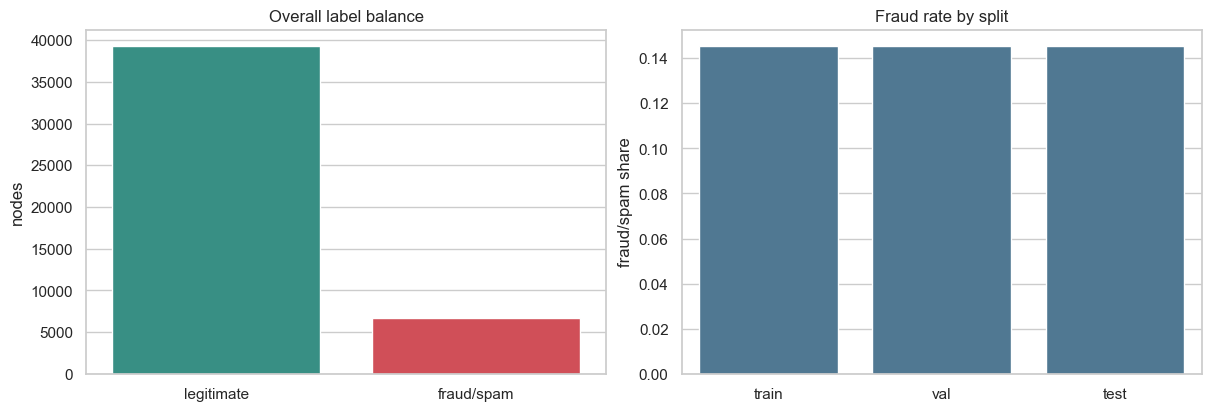

In [27]:
def label_names(y):
    return pd.Series(y).map(LABEL_NAMES)

label_summary = label_names(labels).value_counts().rename_axis("label").reset_index(name="nodes")
label_summary["share"] = label_summary["nodes"] / label_summary["nodes"].sum()
display(label_summary)

split_rows = []
for split, mask in masks.items():
    counts = pd.Series(labels[mask]).value_counts().reindex([0, 1], fill_value=0)
    split_rows.append({
        "split": split,
        "nodes": int(mask.sum()),
        "legitimate": int(counts.loc[0]),
        "fraud_spam": int(counts.loc[1]),
        "fraud_rate": float(counts.loc[1] / mask.sum()),
    })
split_summary = pd.DataFrame(split_rows)
display(split_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.barplot(data=label_summary, x="label", y="nodes", hue="label", palette=[LABEL_COLORS[0], LABEL_COLORS[1]], legend=False, ax=axes[0])
axes[0].set_title("Overall label balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("nodes")

sns.barplot(data=split_summary, x="split", y="fraud_rate", color="#457b9d", ax=axes[1])
axes[1].set_title("Fraud rate by split")
axes[1].set_xlabel("")
axes[1].set_ylabel("fraud/spam share")
plt.show()


## 3. Feature EDA

The YelpChi features are 32 handcrafted review features stored sparsely. We convert them to a dense matrix because the feature count is small.


,mean,std,min,median,max,zero_rate
x_10,0.637029,0.385072,0.018814,0.999985,0.999985,0.000000
x_09,0.592509,0.362085,0.098019,0.510216,1.000000,0.000000
x_26,0.509241,0.353809,0.000000,0.467662,0.995025,0.014536
x_17,0.831301,0.340967,0.122481,0.999974,0.999974,0.000000
x_27,0.515480,0.326228,0.000000,0.517413,0.995025,0.008378
x_25,0.525344,0.323564,0.089552,0.592040,0.995025,0.000000
x_29,0.464007,0.323116,0.034826,0.462687,1.000000,0.000000
x_11,0.524359,0.318121,0.000104,0.503583,0.999985,0.000000
x_12,0.524283,0.317954,0.000801,0.501194,1.000000,0.000000
x_28,0.527980,0.315453,0.000000,0.552239,0.995025,0.008378


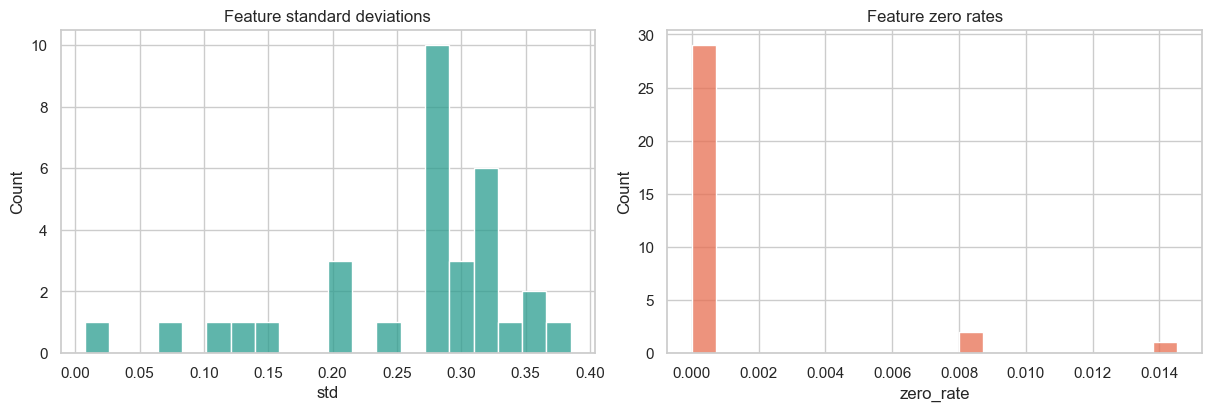

In [28]:
feature_names = [f"x_{i:02d}" for i in range(features.shape[1])]
feature_df = pd.DataFrame(features, columns=feature_names)

feature_summary = pd.DataFrame({
    "mean": feature_df.mean(),
    "std": feature_df.std(),
    "min": feature_df.min(),
    "median": feature_df.median(),
    "max": feature_df.max(),
    "zero_rate": (feature_df == 0).mean(),
}).sort_values("std", ascending=False)
display(feature_summary.head(12))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.histplot(feature_summary["std"], bins=20, color="#2a9d8f", ax=axes[0])
axes[0].set_title("Feature standard deviations")
sns.histplot(feature_summary["zero_rate"], bins=20, color="#e76f51", ax=axes[1])
axes[1].set_title("Feature zero rates")
plt.show()


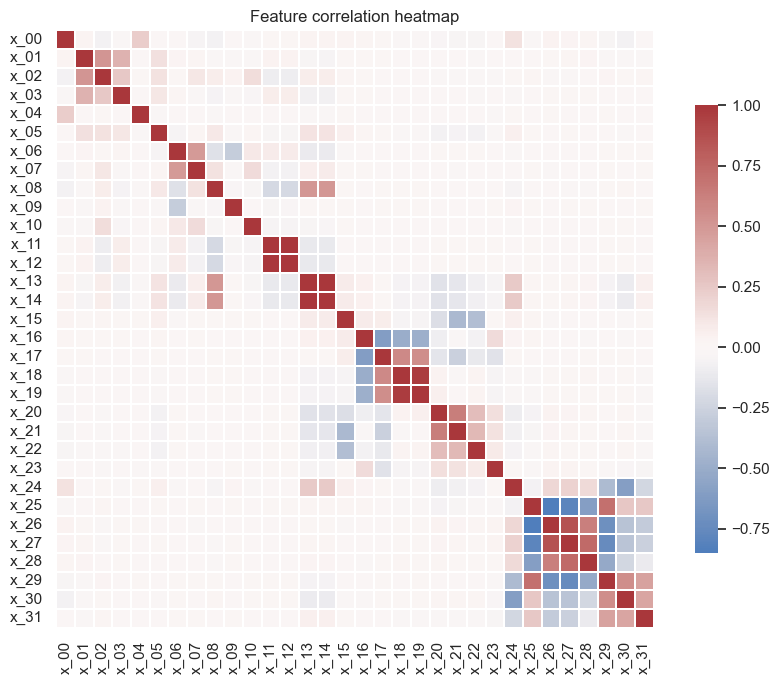

In [29]:
corr = feature_df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", center=0, square=True, linewidths=0.2, cbar_kws={"shrink": 0.75})
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()


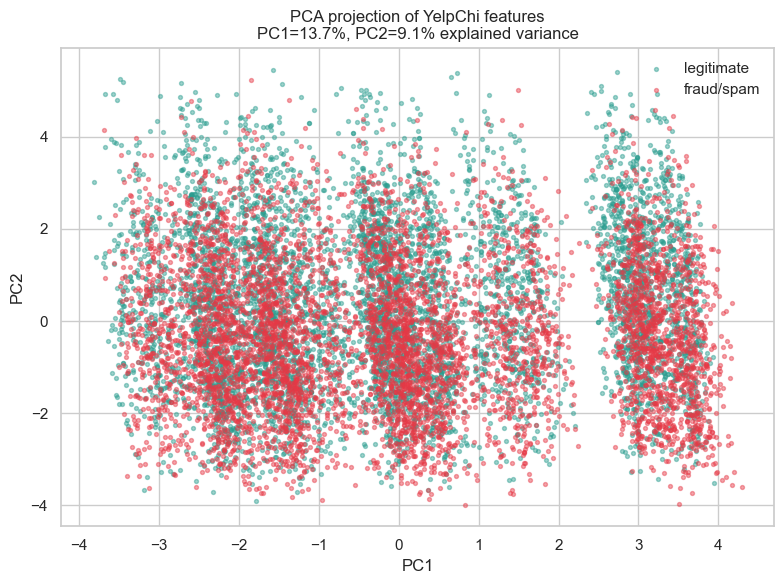

In [30]:
def balanced_sample_indices(y, max_per_class=6_000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    pieces = []
    for label in sorted(np.unique(y)):
        idx = np.flatnonzero(y == label)
        if idx.size > max_per_class:
            idx = rng.choice(idx, size=max_per_class, replace=False)
        pieces.append(idx)
    return np.sort(np.concatenate(pieces))


sample_idx = balanced_sample_indices(labels)
scaled = StandardScaler().fit_transform(features[sample_idx])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pc = pca.fit_transform(scaled)

pca_df = pd.DataFrame({"pc1": pc[:, 0], "pc2": pc[:, 1], "label": labels[sample_idx]})
pca_df["label_name"] = pca_df["label"].map(LABEL_NAMES)

plt.figure(figsize=(8, 6))
for label, name in LABEL_NAMES.items():
    subset = pca_df[pca_df["label"] == label]
    plt.scatter(subset["pc1"], subset["pc2"], s=8, alpha=0.45, label=name, color=LABEL_COLORS[label])
plt.title(
    "PCA projection of YelpChi features\n"
    f"PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%} explained variance"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 4. Graph Structure EDA

We summarize each raw relation and the combined undirected graph. The combined graph is used for simple graph baselines; relation-specific summaries remain useful because the YelpChi graph is multi-relational.


,relation,description,raw_nonzeros,undirected_edges,mean_degree,median_degree,max_degree,isolated_nodes
2,net_rsr,R-S-R: same product and rating,6805486,3402743,148.093441,152.0,465,40
1,net_rtr,R-T-R: same product and month,1147232,573616,24.964791,23.0,118,522
0,net_rur,R-U-R: same user,98630,49315,2.146277,1.0,46,22123


,nodes,undirected_edges,mean_degree,median_degree,max_degree,isolated_nodes
0,45954,3846979,167.427384,168.0,501,13


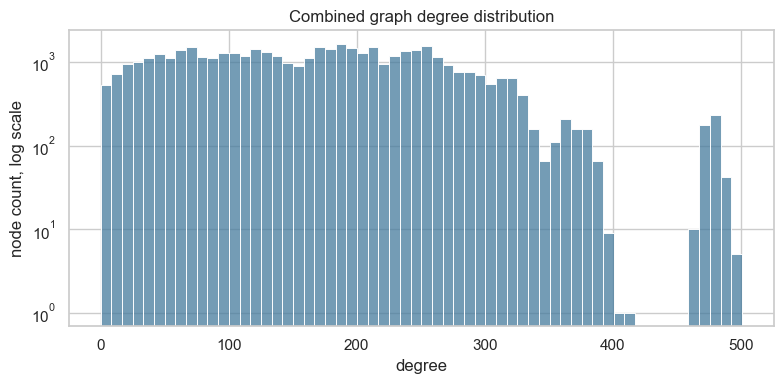

In [31]:
def relation_summary(name, adj):
    undirected = make_undirected_binary(adj)
    rel_degree = np.asarray(undirected.sum(axis=1)).reshape(-1)
    return {
        "relation": name,
        "description": RELATION_INFO.get(name, name),
        "raw_nonzeros": int(adj.nnz),
        "undirected_edges": int(undirected.nnz // 2),
        "mean_degree": float(rel_degree.mean()),
        "median_degree": float(np.median(rel_degree)),
        "max_degree": int(rel_degree.max()),
        "isolated_nodes": int((rel_degree == 0).sum()),
    }


relation_df = pd.DataFrame([relation_summary(name, adj) for name, adj in relation_adjs.items()])
relation_df = relation_df.sort_values("undirected_edges", ascending=False)
display(relation_df)

combined_df = pd.DataFrame([{
    "nodes": combined_adj.shape[0],
    "undirected_edges": combined_adj.nnz // 2,
    "mean_degree": degree.mean(),
    "median_degree": np.median(degree),
    "max_degree": degree.max(),
    "isolated_nodes": int((degree == 0).sum()),
}])
display(combined_df)

plt.figure(figsize=(8, 4))
sns.histplot(degree, bins=60, color="#457b9d")
plt.yscale("log")
plt.title("Combined graph degree distribution")
plt.xlabel("degree")
plt.ylabel("node count, log scale")
plt.tight_layout()
plt.show()


Connected components: 26


,component,nodes,edges,legitimate,fraud_spam,fraud_rate
0,2,45900,3846910,39244,6656,0.145011
1,3,13,47,6,7,0.538462
2,1,6,8,4,2,0.333333
3,0,3,3,2,1,0.333333
4,21,3,3,3,0,0.000000
5,4,2,1,0,2,1.000000
6,5,2,1,0,2,1.000000
7,7,2,1,0,2,1.000000
8,8,2,1,0,2,1.000000
9,13,2,1,2,0,0.000000


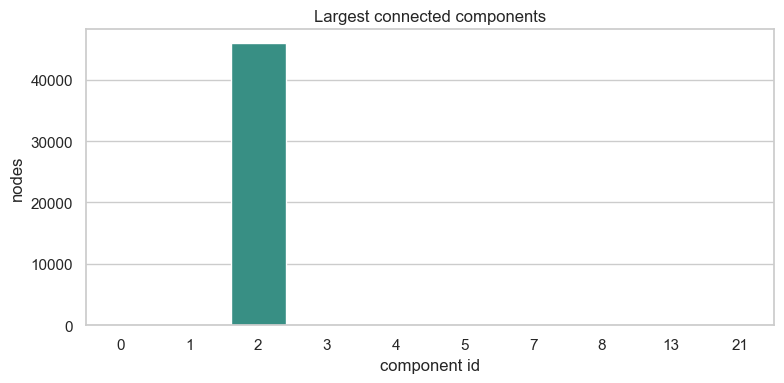

In [32]:
n_components, component_id = connected_components(combined_adj, directed=False, return_labels=True)
component_sizes = pd.Series(component_id).value_counts().rename_axis("component").reset_index(name="nodes")

component_rows = []
for component in component_sizes.head(10)["component"]:
    nodes = np.flatnonzero(component_id == component)
    sub_adj = combined_adj[nodes][:, nodes]
    counts = pd.Series(labels[nodes]).value_counts().reindex([0, 1], fill_value=0)
    component_rows.append({
        "component": int(component),
        "nodes": int(nodes.size),
        "edges": int(sub_adj.nnz // 2),
        "legitimate": int(counts.loc[0]),
        "fraud_spam": int(counts.loc[1]),
        "fraud_rate": float(counts.loc[1] / nodes.size),
    })

component_summary = pd.DataFrame(component_rows)
print(f"Connected components: {n_components:,}")
display(component_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=component_summary, x="component", y="nodes", color="#2a9d8f")
plt.title("Largest connected components")
plt.xlabel("component id")
plt.ylabel("nodes")
plt.tight_layout()
plt.show()


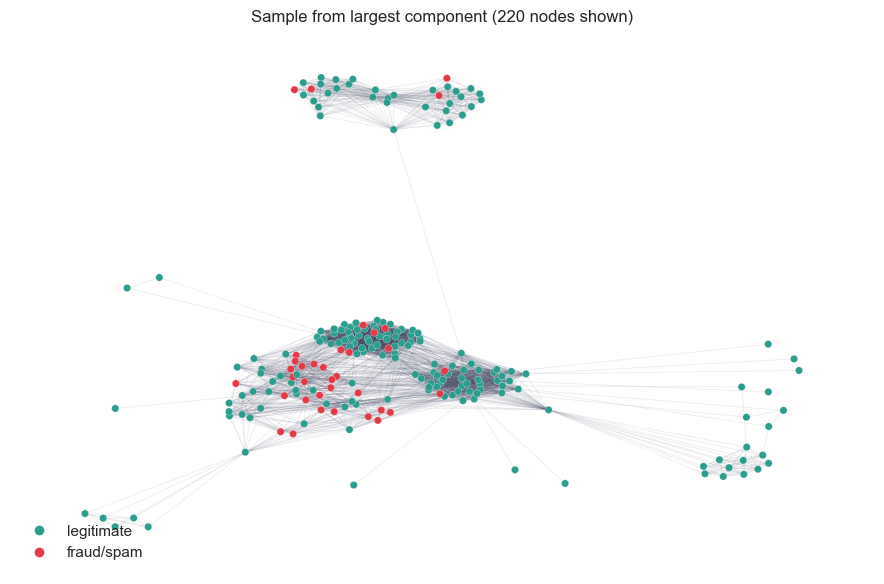

In [33]:
def connected_bfs_sample(adj, component_id, component, y, max_nodes=220):
    nodes = np.flatnonzero(component_id == component)
    if nodes.size <= max_nodes:
        return nodes
    fraud_nodes = nodes[y[nodes] == 1]
    seed = int(fraud_nodes[0] if fraud_nodes.size else nodes[0])
    allowed = set(nodes.tolist())
    seen = {seed}
    queue = [seed]
    out = []
    while queue and len(out) < max_nodes:
        current = queue.pop(0)
        out.append(current)
        nbrs = adj.indices[adj.indptr[current]:adj.indptr[current + 1]]
        for nbr in nbrs:
            nbr = int(nbr)
            if nbr in allowed and nbr not in seen:
                seen.add(nbr)
                queue.append(nbr)
            if len(out) + len(queue) >= max_nodes:
                break
    return np.array(out, dtype=int)


def plot_component_sample(adj, nodes, y, title, output_path=None):
    sub_adj = adj[nodes][:, nodes]
    if sub_adj.nnz // 2 > 4_000:
        coo = sparse.triu(sub_adj, k=1).tocoo()
        rng = np.random.default_rng(RANDOM_STATE)
        keep = rng.choice(coo.nnz, size=4_000, replace=False)
        rows = np.concatenate([coo.row[keep], coo.col[keep]])
        cols = np.concatenate([coo.col[keep], coo.row[keep]])
        sub_adj = sparse.coo_matrix((np.ones(rows.size), (rows, cols)), shape=sub_adj.shape).tocsr()

    graph = nx.from_scipy_sparse_array(sub_adj)
    pos = nx.spring_layout(graph, seed=RANDOM_STATE, k=0.2, iterations=60)
    colors = [LABEL_COLORS[int(y[nodes[i]])] for i in graph.nodes]
    plt.figure(figsize=(9, 6))
    nx.draw_networkx_edges(graph, pos, alpha=0.12, width=0.5, edge_color="#4a4e69")
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=28, linewidths=0.2, edgecolors="white")
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", label=name, markerfacecolor=LABEL_COLORS[label], markersize=8)
        for label, name in LABEL_NAMES.items()
    ]
    plt.legend(handles=handles, loc="lower left", frameon=False)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


largest_component = int(component_summary.iloc[0]["component"])
sample_nodes = connected_bfs_sample(combined_adj, component_id, largest_component, labels)
plot_component_sample(
    combined_adj,
    sample_nodes,
    labels,
    f"Sample from largest component ({len(sample_nodes):,} nodes shown)",
    output_path=FIGURE_DIR / "yelpchi_largest_component_sample.png",
)


## 5. Homophily And Neighborhood Signals

These summaries parallel the Bitcoin notebook's transition and neighborhood tables. They also tell us whether graph-only baselines should have any signal.


In [ ]:
def edge_transition_table(adj, y):
    edges = sparse.triu(make_undirected_binary(adj), k=1).tocoo()
    src = pd.Series(y[edges.row]).map(LABEL_NAMES)
    dst = pd.Series(y[edges.col]).map(LABEL_NAMES)
    table = pd.crosstab(src, dst, rownames=["source label"], colnames=["target label"])
    return table.reindex(index=list(LABEL_NAMES.values()), columns=list(LABEL_NAMES.values()), fill_value=0)

display(edge_transition_table(combined_adj, labels))

homophily_rows = []
for name, adj in {"combined": combined_adj, **relation_adjs}.items():
    undirected = make_undirected_binary(adj)
    edges = sparse.triu(undirected, k=1).tocoo()
    homophily = float(np.mean(labels[edges.row] == labels[edges.col])) if edges.nnz else np.nan
    homophily_rows.append({
        "graph": name,
        "description": RELATION_INFO.get(name, name),
        "undirected_edges": int(edges.nnz),
        "edge_homophily": homophily,
    })
homophily_df = pd.DataFrame(homophily_rows).sort_values("edge_homophily", ascending=False)
display(homophily_df)

target label,legitimate,fraud/spam
source label,,
legitimate,2875606,868556
fraud/spam,4536,98281


,graph,description,undirected_edges,edge_homophily
1,net_rur,R-U-R: same user,49315,0.996431
0,combined,combined,3846979,0.773045
3,net_rsr,R-S-R: same product and rating,3402743,0.772208
2,net_rtr,R-T-R: same product and month,573616,0.759330


In [35]:
fraud_neighbor_count = combined_adj @ (labels == 1).astype(float)
legit_neighbor_count = combined_adj @ (labels == 0).astype(float)
fraud_neighbor_rate = np.divide(fraud_neighbor_count, np.maximum(degree, 1))

neighborhood_df = pd.DataFrame({
    "node": np.arange(labels.size),
    "label": labels,
    "label_name": label_names(labels),
    "degree": degree,
    "legitimate_neighbors": legit_neighbor_count,
    "fraud_spam_neighbors": fraud_neighbor_count,
    "fraud_neighbor_rate": fraud_neighbor_rate,
    "has_fraud_neighbor": fraud_neighbor_count > 0,
})

neighborhood_summary = (
    neighborhood_df
    .groupby("label_name")
    .agg(
        nodes=("node", "size"),
        mean_degree=("degree", "mean"),
        median_degree=("degree", "median"),
        mean_fraud_neighbors=("fraud_spam_neighbors", "mean"),
        mean_fraud_neighbor_rate=("fraud_neighbor_rate", "mean"),
        pct_with_fraud_neighbor=("has_fraud_neighbor", "mean"),
    )
    .reset_index()
)
display(neighborhood_summary)
display(neighborhood_df.sort_values(["label", "fraud_neighbor_rate", "degree"], ascending=[False, False, False]).head(10))


,label_name,nodes,mean_degree,median_degree,mean_fraud_neighbors,mean_fraud_neighbor_rate,pct_with_fraud_neighbor
0,fraud/spam,6677,160.199790,158.0,29.438670,0.194625,0.992212
1,legitimate,39277,168.656058,170.0,22.229091,0.132446,0.975787


,node,label,label_name,degree,legitimate_neighbors,fraud_spam_neighbors,fraud_neighbor_rate,has_fraud_neighbor
6071,6071,1,fraud/spam,22,0.0,22.0,1.0,True
6058,6058,1,fraud/spam,20,0.0,20.0,1.0,True
6063,6063,1,fraud/spam,20,0.0,20.0,1.0,True
6054,6054,1,fraud/spam,19,0.0,19.0,1.0,True
6077,6077,1,fraud/spam,19,0.0,19.0,1.0,True
6079,6079,1,fraud/spam,19,0.0,19.0,1.0,True
6092,6092,1,fraud/spam,19,0.0,19.0,1.0,True
6051,6051,1,fraud/spam,18,0.0,18.0,1.0,True
6053,6053,1,fraud/spam,18,0.0,18.0,1.0,True
6060,6060,1,fraud/spam,18,0.0,18.0,1.0,True


## 6. Baseline Graph Prediction

All label-derived graph features below use training labels only. Validation labels tune a score threshold. Test labels are used only for final metrics.


In [ ]:
def best_f1_threshold(y_true, scores):
    # after getting the scores from model, tune a best threshold for max F1 score
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    candidates = np.unique(np.concatenate([
        np.linspace(0.01, 0.99, 99),
        np.quantile(scores, np.linspace(0, 1, 101)),
    ]))
    best_threshold, best_score = 0.5, -np.inf
    for threshold in candidates:
        pred = (scores >= threshold).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_score:
            best_threshold, best_score = float(threshold), score
    return best_threshold


def evaluate_scores(model_name, scores):
    # evaluate the model scores with threshold tuned
    threshold = best_f1_threshold(labels[val_mask], scores[val_mask])
    y_test = labels[test_mask]
    s_test = scores[test_mask]
    pred = (s_test >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_test, s_test),
        "average_precision": average_precision_score(y_test, s_test),
        "f1": f1_score(y_test, pred, zero_division=0),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "accuracy": accuracy_score(y_test, pred),
    }


def classifier_scores(model, x):
    model.fit(x[train_mask], labels[train_mask])
    return model.predict_proba(x)[:, 1]


def row_normalize(adj):
    adj = sparse.csr_matrix(adj, dtype=np.float32)
    row_sum = np.asarray(adj.sum(axis=1)).reshape(-1)
    inv = np.divide(1.0, row_sum, out=np.zeros_like(row_sum, dtype=np.float32), where=row_sum > 0)
    return sparse.diags(inv) @ adj


def neighbor_vote_scores(adj, y, train_mask, smoothing=1.0):
    prior = float(y[train_mask].mean())
    known = train_mask.astype(float)
    positive = ((y == 1) & train_mask).astype(float)
    known_nbrs = adj @ known
    positive_nbrs = adj @ positive
    return (positive_nbrs + smoothing * prior) / (known_nbrs + smoothing)


def label_propagation_scores(adj, y, train_mask, alpha=0.85, n_iter=30):
    prior = float(y[train_mask].mean())
    transition = row_normalize(adj)
    scores = np.full(y.size, prior, dtype=np.float32)
    scores[train_mask] = y[train_mask].astype(np.float32)
    for _ in range(n_iter):
        scores = alpha * (transition @ scores) + (1 - alpha) * prior
        scores[train_mask] = y[train_mask].astype(np.float32)
    return np.clip(scores, 0, 1)


def graph_stat_features(adj, relation_adjs, y, train_mask):
    # extract graph features
    prior = float(y[train_mask].mean())
    known = train_mask.astype(float)
    positive = ((y == 1) & train_mask).astype(float)
    deg = np.asarray(adj.sum(axis=1)).reshape(-1)
    known_nbrs = adj @ known
    positive_nbrs = adj @ positive
    pieces = [
        np.log1p(deg), # log (1+degree)
        np.log1p(known_nbrs), # log (1+known neighbors)
        positive_nbrs, # fraud neighbors
        (positive_nbrs + prior) / (known_nbrs + 1.0), # percentage of fraud neighbor
        (positive_nbrs > 0).astype(float), # has fraud neighbor
    ]

    for rel_adj in relation_adjs.values():
        rel = make_undirected_binary(rel_adj)
        rel_deg = np.asarray(rel.sum(axis=1)).reshape(-1)
        rel_known = rel @ known
        rel_pos = rel @ positive
        pieces.extend([
            np.log1p(rel_deg), # log(1+type-i-degree)
            (rel_pos + prior) / (rel_known + 1.0), # percentage of fraud neighbor in terms of type-i edge, 
        ])
    return np.column_stack(pieces).astype(np.float32)


In [37]:
baseline_scores = {}
baseline_results = []

prior_model = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
baseline_scores["Class prior"] = classifier_scores(prior_model, features)
baseline_results.append(evaluate_scores("Class prior", baseline_scores["Class prior"]))

feature_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE),
)
baseline_scores["Feature logistic regression"] = classifier_scores(feature_lr, features)
baseline_results.append(evaluate_scores("Feature logistic regression", baseline_scores["Feature logistic regression"]))

baseline_scores["Neighbor-label vote"] = neighbor_vote_scores(combined_adj, labels, train_mask)
baseline_results.append(evaluate_scores("Neighbor-label vote", baseline_scores["Neighbor-label vote"]))

baseline_scores["Graph label propagation"] = label_propagation_scores(combined_adj, labels, train_mask)
baseline_results.append(evaluate_scores("Graph label propagation", baseline_scores["Graph label propagation"]))

graph_features = graph_stat_features(combined_adj, relation_adjs, labels, train_mask)
feature_plus_graph = np.column_stack([features, graph_features])
graph_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE),
)
baseline_scores["Feature + graph-stat logistic regression"] = classifier_scores(graph_lr, feature_plus_graph)
baseline_results.append(evaluate_scores("Feature + graph-stat logistic regression", baseline_scores["Feature + graph-stat logistic regression"]))

self_loop_adj = combined_adj + sparse.eye(combined_adj.shape[0], format="csr")
smoothed_features = row_normalize(self_loop_adj) @ features
feature_plus_smooth = np.column_stack([features, smoothed_features])
smooth_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE),
)
baseline_scores["Feature smoothing logistic regression"] = classifier_scores(smooth_lr, feature_plus_smooth)
baseline_results.append(evaluate_scores("Feature smoothing logistic regression", baseline_scores["Feature smoothing logistic regression"]))

results_df = pd.DataFrame(baseline_results).sort_values("average_precision", ascending=False)
display(results_df)


,model,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,accuracy
4,Feature + graph-stat logistic regression,0.739294,0.905941,0.669197,0.599857,0.574366,0.627715,0.774334,0.878359
5,Feature smoothing logistic regression,0.606380,0.780190,0.409377,0.433914,0.350554,0.569288,0.695031,0.784245
1,Feature logistic regression,0.635524,0.772243,0.398334,0.411510,0.350554,0.498127,0.670652,0.793058
2,Neighbor-label vote,0.164160,0.651563,0.283255,0.314706,0.233880,0.480899,0.606603,0.695789
3,Graph label propagation,0.160000,0.649902,0.279658,0.318398,0.239098,0.476404,0.609384,0.703732
0,Class prior,0.010000,0.500000,0.145251,0.253658,0.145251,1.000000,0.500000,0.145251


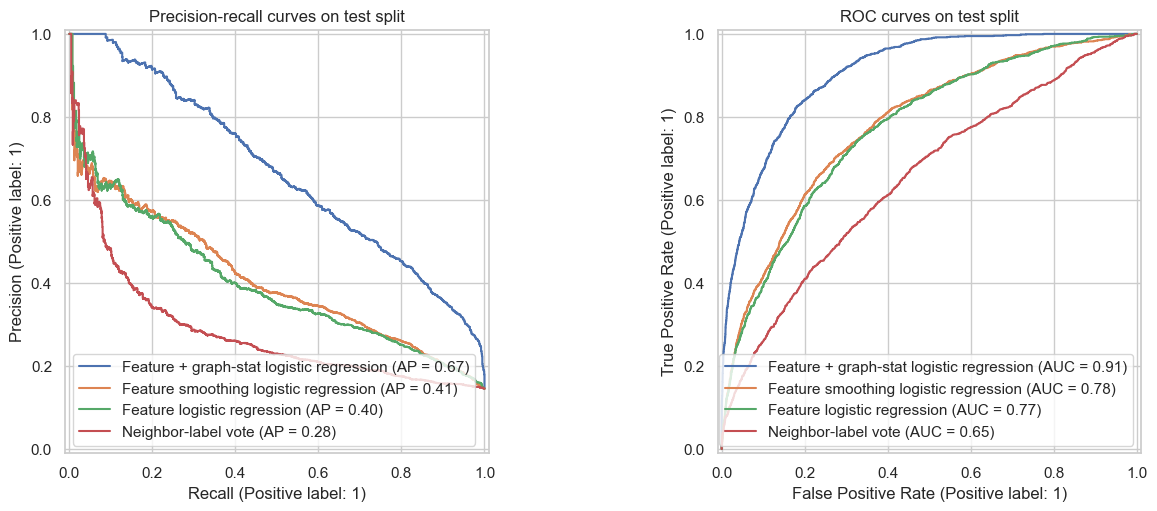

In [17]:
top_models = results_df.head(min(4, len(results_df)))["model"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for name in top_models:
    scores = baseline_scores[name]
    PrecisionRecallDisplay.from_predictions(labels[test_mask], scores[test_mask], name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(labels[test_mask], scores[test_mask], name=name, ax=axes[1])

axes[0].set_title("Precision-recall curves on test split")
axes[1].set_title("ROC curves on test split")
plt.show()


## 7. Graph Neural Nets

This section runs the GNN comparison on the full YelpChi graph. 

In [ ]:
import random
import time

import torch
from torch import nn
import torch.nn.functional as F

TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GCN_EPOCHS = 200
GAT_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 12
LEARNING_RATE = 0.01
WEIGHT_DECAY = 5e-4
DROPOUT = 0.35
GAT_HIDDEN_DIM = 8
RELATION_GAT_HIDDEN_DIM = 6

def set_torch_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_torch_seed(RANDOM_STATE)
print(f"torch: {torch.__version__}")
print(f"device: {TORCH_DEVICE}")


torch: 2.11.0+cu128
device: cuda


### 7.1 Full Graph And Split

The graph below uses every YelpChi review node. The split is exactly the full-data split used by Section 6, so the GNN rows are directly comparable to the earlier logistic and graph-stat baseline rows.


In [ ]:
X_raw = features.astype(np.float32, copy=False)
y_full = labels.astype(np.int64, copy=False)
A_full = combined_adj.tocsr()
relation_adjs_full = {
    name: make_undirected_binary(adj)
    for name, adj in relation_adjs.items()
}

# Fit preprocessing on training nodes only to avoid validation/test leakage.
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit(X_raw[train_mask]).transform(X_raw).astype(np.float32)

# Make the split visible before launching expensive model cells.
split_summary = pd.DataFrame({
    "split": ["train", "validation/calibration", "test"],
    "nodes": [train_mask.sum(), val_mask.sum(), test_mask.sum()],
    "fraud_spam": [
        int((y_full[train_mask] == 1).sum()),
        int((y_full[val_mask] == 1).sum()),
        int((y_full[test_mask] == 1).sum()),
    ],
    "legitimate": [
        int((y_full[train_mask] == 0).sum()),
        int((y_full[val_mask] == 0).sum()),
        int((y_full[test_mask] == 0).sum()),
    ],
})

print(f"full graph: {A_full.shape[0]:,} nodes, {A_full.nnz // 2:,} undirected edges")
print("full relation edges:", {name: adj.nnz // 2 for name, adj in relation_adjs_full.items()})
display(split_summary)


full graph: 45,954 nodes, 3,846,979 undirected edges
full relation edges: {'net_rur': 49315, 'net_rtr': 573616, 'net_rsr': 3402743}


,split,nodes,fraud_spam,legitimate
0,train,27572,4006,23566
1,validation/calibration,9191,1336,7855
2,test,9191,1335,7856


In [51]:
# GCN needs D^{-1/2}(A+I)D^{-1/2} as a torch sparse tensor.
def to_torch_normalized_adjacency(adj, device=TORCH_DEVICE):
    adj = sparse.csr_matrix(adj, dtype=np.float32)
    adj = adj + sparse.eye(adj.shape[0], dtype=np.float32, format="csr")
    degree = np.asarray(adj.sum(axis=1)).reshape(-1)
    inv_sqrt = np.divide(1.0, np.sqrt(degree), out=np.zeros_like(degree, dtype=np.float32), where=degree > 0)
    normalized = sparse.diags(inv_sqrt) @ adj @ sparse.diags(inv_sqrt)
    coo = normalized.tocoo()
    indices = torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long, device=device)
    values = torch.tensor(coo.data, dtype=torch.float32, device=device)
    return torch.sparse_coo_tensor(indices, values, size=coo.shape, device=device).coalesce()


# GAT uses explicit directed edge indices, including self-loops.
def to_torch_edge_index(adj, device=TORCH_DEVICE):
    adj = sparse.csr_matrix(adj, dtype=np.float32)
    adj = adj + sparse.eye(adj.shape[0], dtype=np.float32, format="csr")
    coo = adj.tocoo()
    return torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long, device=device)


# Convert all fixed arrays once; model cells below only reference tensors.
x_t = torch.tensor(X_scaled, dtype=torch.float32, device=TORCH_DEVICE)
y_t = torch.tensor(y_full, dtype=torch.float32, device=TORCH_DEVICE)
train_idx_t = torch.tensor(np.flatnonzero(train_mask), dtype=torch.long, device=TORCH_DEVICE)

adj_norm_t = to_torch_normalized_adjacency(A_full, TORCH_DEVICE)
edge_index_t = to_torch_edge_index(A_full, TORCH_DEVICE)
relation_adj_norm_t = {
    name: to_torch_normalized_adjacency(adj, TORCH_DEVICE)
    for name, adj in relation_adjs_full.items()
}
relation_edge_index_t = {
    name: to_torch_edge_index(adj, TORCH_DEVICE)
    for name, adj in relation_adjs_full.items()
}

# Weight BCE so fraud nodes are not overwhelmed by the majority class.
positive_train = float((y_full[train_mask] == 1).sum())
negative_train = float((y_full[train_mask] == 0).sum())
pos_weight = torch.tensor([negative_train / max(positive_train, 1.0)], dtype=torch.float32, device=TORCH_DEVICE)

print(f"BCE positive-class weight: {pos_weight.item():.3f}")
print(f"normalized adjacency entries: {adj_norm_t._nnz():,}")
print(f"homo edge-index entries including self-loops: {edge_index_t.shape[1]:,}")
print("relation edge-index entries:", {name: edge_index.shape[1] for name, edge_index in relation_edge_index_t.items()})


BCE positive-class weight: 5.883
normalized adjacency entries: 7,739,912
homo edge-index entries including self-loops: 7,739,912
relation edge-index entries: {'net_rur': 144584, 'net_rtr': 1193186, 'net_rsr': 6851440}


### 7.2 GCN Family

In [ ]:
from tqdm import tqdm

def reset_torch_seed(offset=0):
    set_torch_seed(RANDOM_STATE + offset)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.35):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x):
        h = F.relu(self.lin1(x))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.lin2(h).squeeze(-1)


class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.35, residual_mlp=False):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)
        self.skip = MLP(in_dim, hidden_dim, dropout) if residual_mlp else None
        self.dropout = dropout

    def forward(self, x, adj_norm):
        h = torch.sparse.mm(adj_norm, x)
        h = F.relu(self.lin1(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = torch.sparse.mm(adj_norm, h)
        out = self.lin2(h).squeeze(-1)
        if self.skip is not None:
            out = out + self.skip(x)
        return out


# separate message channels for 3 types of edges
class RelationGCN(nn.Module):
    def __init__(self, in_dim, relation_names, hidden_dim=48, dropout=0.35, residual_mlp=True):
        super().__init__()
        self.relations = list(relation_names)
        self.rel1 = nn.ModuleDict({name: nn.Linear(in_dim, hidden_dim, bias=False) for name in self.relations})
        self.self1 = nn.Linear(in_dim, hidden_dim)
        self.rel2 = nn.ModuleDict({name: nn.Linear(hidden_dim, 1, bias=False) for name in self.relations})
        self.self2 = nn.Linear(hidden_dim, 1)
        self.skip = MLP(in_dim, hidden_dim, dropout) if residual_mlp else None
        self.dropout = dropout

    def forward(self, x, relation_adjs):
        h = self.self1(x)
        for name, adj_norm in relation_adjs.items():
            h = h + self.rel1[name](torch.sparse.mm(adj_norm, x))
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.self2(h)
        for name, adj_norm in relation_adjs.items():
            out = out + self.rel2[name](torch.sparse.mm(adj_norm, h))
        out = out.squeeze(-1)
        if self.skip is not None:
            out = out + self.skip(x)
        return out


# Train with early stopping on validation AP; final F1 is still calibrated by evaluate_scores().
def train_torch_model(model, forward_fn, max_epochs=80, lr=0.01, weight_decay=5e-4, patience=12, seed_offset=0):
    reset_torch_seed(seed_offset)
    model = model.to(TORCH_DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best_state = None
    best_val_ap = -np.inf
    best_epoch = 0
    patience_left = patience
    history = []

    for epoch in tqdm(range(1, max_epochs + 1)):
        model.train()
        optimizer.zero_grad()
        logits = forward_fn(model)
        loss = criterion(logits[train_idx_t], y_t[train_idx_t])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            scores = torch.sigmoid(forward_fn(model)).detach().cpu().numpy()
        val_ap = average_precision_score(labels[val_mask], scores[val_mask])
        val_threshold = best_f1_threshold(labels[val_mask], scores[val_mask])
        val_f1 = f1_score(labels[val_mask], (scores[val_mask] >= val_threshold).astype(int), zero_division=0)
        history.append({"epoch": epoch, "loss": float(loss.detach().cpu()), "val_ap": val_ap, "val_f1": val_f1})

        if val_ap > best_val_ap + 1e-5:
            best_val_ap = val_ap
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        final_scores = torch.sigmoid(forward_fn(model)).detach().cpu().numpy()
    return final_scores, pd.DataFrame(history), best_epoch

gnn_rows = []
gnn_scores = {}

gcn_specs = [
    ("MLP", lambda: MLP(X_scaled.shape[1], hidden_dim=64, dropout=DROPOUT), lambda model: model(x_t)),
    ("GCN", lambda: GCN(X_scaled.shape[1], hidden_dim=64, dropout=DROPOUT, residual_mlp=False), lambda model: model(x_t, adj_norm_t)),
    ("Residual GCN", lambda: GCN(X_scaled.shape[1], hidden_dim=64, dropout=DROPOUT, residual_mlp=True), lambda model: model(x_t, adj_norm_t)),
    (
        "Relation GCN + MLP skip",
        lambda: RelationGCN(X_scaled.shape[1], relation_adj_norm_t.keys(), hidden_dim=48, dropout=DROPOUT, residual_mlp=True),
        lambda model: model(x_t, relation_adj_norm_t),
    ),
]

for seed_offset, (name, model_factory, forward_fn) in enumerate(gcn_specs, start=10):
    reset_torch_seed(seed_offset)
    model = model_factory()
    t0 = time.perf_counter()
    scores, history, best_epoch = train_torch_model(
        model,
        forward_fn,
        max_epochs=GCN_EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        patience=EARLY_STOPPING_PATIENCE,
        seed_offset=seed_offset,
    )
    row = evaluate_scores(name, scores)
    row["best_epoch"] = best_epoch
    row["runtime_sec"] = time.perf_counter() - t0
    gnn_scores[name] = scores
    gnn_rows.append(row)
    print(f"{name}: F1={row['f1']:.3f}, AP={row['average_precision']:.3f}, best_epoch={best_epoch}, runtime={row['runtime_sec']:.2f}s")

display(pd.DataFrame(gnn_rows).sort_values("f1", ascending=False))


 84%|████████▍ | 168/200 [00:41<00:07,  4.02it/s]


MLP: F1=0.547, AP=0.576, best_epoch=157, runtime=42.03s


 56%|█████▌    | 111/200 [00:35<00:28,  3.11it/s]


GCN: F1=0.318, AP=0.274, best_epoch=100, runtime=35.91s


100%|██████████| 200/200 [01:01<00:00,  3.25it/s]


Residual GCN: F1=0.571, AP=0.621, best_epoch=195, runtime=61.77s


100%|██████████| 200/200 [01:02<00:00,  3.19it/s]


Relation GCN + MLP skip: F1=0.709, AP=0.777, best_epoch=198, runtime=63.03s


,model,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,accuracy,best_epoch,runtime_sec
3,Relation GCN + MLP skip,0.740402,0.939147,0.776652,0.708908,0.705490,0.712360,0.830912,0.915026,198,63.030969
2,Residual GCN,0.705217,0.870108,0.621479,0.571209,0.587490,0.555805,0.744743,0.878794,195,61.770449
0,MLP,0.660000,0.853563,0.576158,0.547183,0.500310,0.603745,0.750638,0.854858,157,42.034384
1,GCN,0.525266,0.651258,0.273634,0.317916,0.246395,0.447940,0.607562,0.720814,100,35.906583


### 7.3 GAT Family

In [ ]:
# Segment softmax over incoming edges for each destination node
def edge_softmax(scores, dst, num_nodes):
    num_heads = scores.shape[1]
    index = dst[:, None].expand(-1, num_heads)
    max_per_dst = torch.full((num_nodes, num_heads), -1e15, dtype=scores.dtype, device=scores.device)
    max_per_dst.scatter_reduce_(0, index, scores, reduce="amax", include_self=True)
    shifted = scores - max_per_dst[dst]
    exp_scores = torch.exp(shifted)
    denom = torch.zeros((num_nodes, num_heads), dtype=scores.dtype, device=scores.device)
    denom.scatter_add_(0, index, exp_scores)
    return exp_scores / (denom[dst] + 1e-16)


class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=2, concat=True, dropout=0.35, negative_slope=0.2):
        super().__init__()
        self.heads = heads
        self.out_dim = out_dim
        self.concat = concat
        self.dropout = dropout
        self.linear = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.attn_src = nn.Parameter(torch.empty(heads, out_dim))
        self.attn_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.bias = nn.Parameter(torch.zeros(heads * out_dim if concat else out_dim))
        self.negative_slope = negative_slope
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.xavier_uniform_(self.attn_src)
        nn.init.xavier_uniform_(self.attn_dst)

    def forward(self, x, edge_index):
        src, dst = edge_index[0], edge_index[1]
        num_nodes = x.shape[0]
        h = self.linear(x).view(num_nodes, self.heads, self.out_dim)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h_src = h[src]
        h_dst = h[dst]
        scores = (h_src * self.attn_src).sum(dim=-1) + (h_dst * self.attn_dst).sum(dim=-1)
        scores = F.leaky_relu(scores, negative_slope=self.negative_slope)
        alpha = edge_softmax(scores, dst, num_nodes)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        messages = h_src * alpha.unsqueeze(-1)
        out = torch.zeros((num_nodes, self.heads, self.out_dim), dtype=x.dtype, device=x.device)
        out.index_add_(0, dst, messages)
        if self.concat:
            out = out.reshape(num_nodes, self.heads * self.out_dim)
        else:
            out = out.mean(dim=1)
        return out + self.bias


class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim=8, heads=2, dropout=0.35, residual_mlp=False):
        super().__init__()
        self.gat1 = GATLayer(in_dim, hidden_dim, heads=heads, concat=True, dropout=dropout)
        self.gat2 = GATLayer(hidden_dim * heads, 1, heads=1, concat=False, dropout=dropout)
        self.skip = MLP(in_dim, 64, dropout) if residual_mlp else None
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = self.gat1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.gat2(h, edge_index).squeeze(-1)
        if self.skip is not None:
            out = out + self.skip(x)
        return out

class RelationGAT(nn.Module):
    def __init__(self, in_dim, relation_names, hidden_dim=4, heads=2, dropout=0.35, residual_mlp=True):
        super().__init__()
        self.relations = list(relation_names)
        self.layers = nn.ModuleDict({
            name: GATLayer(in_dim, hidden_dim, heads=heads, concat=True, dropout=dropout)
            for name in self.relations
        })
        self.out = nn.Linear(hidden_dim * heads * len(self.relations), 1)
        self.skip = MLP(in_dim, 64, dropout) if residual_mlp else None
        self.dropout = dropout

    def forward(self, x, relation_edges):
        relation_outputs = [F.elu(self.layers[name](x, edge_index)) for name, edge_index in relation_edges.items()]
        h = torch.cat(relation_outputs, dim=1)
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.out(h).squeeze(-1)
        if self.skip is not None:
            out = out + self.skip(x)
        return out

gat_specs = [
    ("GAT", lambda: GAT(X_scaled.shape[1], hidden_dim=GAT_HIDDEN_DIM, heads=2, dropout=DROPOUT, residual_mlp=False), lambda model: model(x_t, edge_index_t)),
    ("Residual GAT", lambda: GAT(X_scaled.shape[1], hidden_dim=GAT_HIDDEN_DIM, heads=2, dropout=DROPOUT, residual_mlp=True), lambda model: model(x_t, edge_index_t)),
    (
        "Relation GAT + MLP skip",
        lambda: RelationGAT(X_scaled.shape[1], relation_edge_index_t.keys(), hidden_dim=RELATION_GAT_HIDDEN_DIM, heads=2, dropout=DROPOUT, residual_mlp=True),
        lambda model: model(x_t, relation_edge_index_t),
    ),
]

for seed_offset, (name, model_factory, forward_fn) in enumerate(gat_specs, start=30):
    reset_torch_seed(seed_offset)
    model = model_factory()
    t0 = time.perf_counter()
    scores, history, best_epoch = train_torch_model(
        model,
        forward_fn,
        max_epochs=GAT_EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        patience=EARLY_STOPPING_PATIENCE,
        seed_offset=seed_offset,
    )
    row = evaluate_scores(name, scores)
    row["best_epoch"] = best_epoch
    row["runtime_sec"] = time.perf_counter() - t0
    gnn_scores[name] = scores
    gnn_rows.append(row)
    print(f"{name}: F1={row['f1']:.3f}, AP={row['average_precision']:.3f}, best_epoch={best_epoch}, runtime={row['runtime_sec']:.2f}s")

display(pd.DataFrame(gnn_rows).sort_values("f1", ascending=False))


 82%|████████▏ | 41/50 [00:21<00:04,  1.93it/s]

### 7.4 F1 Comparison

This table is the full-graph comparison: feature-only neural baseline, GCN variants, and GAT variants all use the same full YelpChi train/validation/test split.


,model,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,accuracy,best_epoch,runtime_sec
9,Relation GCN + MLP skip,0.740402,0.939147,0.776652,0.708908,0.705490,0.712360,0.830912,0.915026,198.0,63.030969
13,Relation GAT + MLP skip,0.740000,0.890147,0.662752,0.608397,0.620233,0.597004,0.767443,0.888369,156.0,67.175235
16,Relation GAT + MLP skip,0.740000,0.889562,0.661613,0.607498,0.620797,0.594757,0.766510,0.888369,155.0,81.634615
4,Feature + graph-stat logistic regression,0.739294,0.905941,0.669197,0.599857,0.574366,0.627715,0.774334,0.878359,NaN,NaN
8,Residual GCN,0.705217,0.870108,0.621479,0.571209,0.587490,0.555805,0.744743,0.878794,195.0,61.770449
12,Residual GAT,0.720000,0.859163,0.591513,0.547315,0.534237,0.561049,0.738964,0.865194,200.0,95.616818
6,MLP,0.660000,0.853563,0.576158,0.547183,0.500310,0.603745,0.750638,0.854858,157.0,42.034384
15,Residual GAT,0.710000,0.859119,0.589927,0.546757,0.524038,0.571536,0.741661,0.862365,200.0,147.460992
5,Feature smoothing logistic regression,0.606380,0.780190,0.409377,0.433914,0.350554,0.569288,0.695031,0.784245,NaN,NaN
1,Feature logistic regression,0.635524,0.772243,0.398334,0.411510,0.350554,0.498127,0.670652,0.793058,NaN,NaN


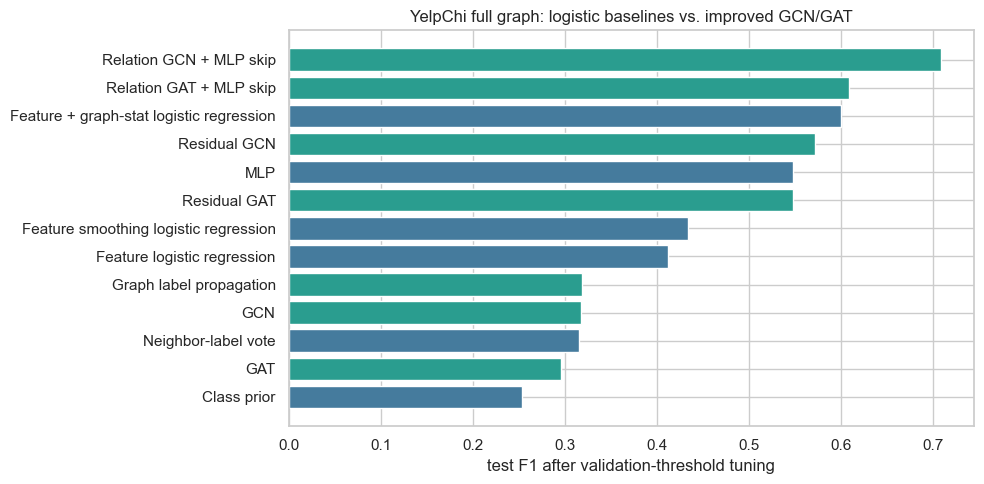

In [99]:
# Combine Section 6 baselines and all GNN variants into one table.
gnn_results_df = pd.DataFrame(baseline_results + gnn_rows).sort_values("f1", ascending=False)
display(gnn_results_df)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = gnn_results_df.sort_values("f1", ascending=True)
colors = ["#2a9d8f" if "gcn" in name.lower() or "gat" in name.lower() else "#457b9d" for name in plot_df["model"]]
ax.barh(plot_df["model"], plot_df["f1"], color=colors)
ax.set_xlabel("test F1 after validation-threshold tuning")
ax.set_title("YelpChi full graph: logistic baselines vs. improved GCN/GAT")
plt.tight_layout()
plt.show()


### 7.5 AUPRC And AUROC Analysis

,model,f1,auprc,auroc,precision,recall,balanced_accuracy,accuracy,threshold,best_epoch,runtime_sec
3,Relation GCN + MLP skip,0.708908,0.776652,0.939147,0.705490,0.712360,0.830912,0.915026,0.740402,198,63.030969
7,Relation GAT + MLP skip,0.608397,0.662752,0.890147,0.620233,0.597004,0.767443,0.888369,0.740000,156,67.175235
10,Relation GAT + MLP skip,0.607498,0.661613,0.889562,0.620797,0.594757,0.766510,0.888369,0.740000,155,81.634615
2,Residual GCN,0.571209,0.621479,0.870108,0.587490,0.555805,0.744743,0.878794,0.705217,195,61.770449
6,Residual GAT,0.547315,0.591513,0.859163,0.534237,0.561049,0.738964,0.865194,0.720000,200,95.616818
9,Residual GAT,0.546757,0.589927,0.859119,0.524038,0.571536,0.741661,0.862365,0.710000,200,147.460992
1,GCN,0.317916,0.273634,0.651258,0.246395,0.447940,0.607562,0.720814,0.525266,100,35.906583
5,GAT,0.295737,0.249674,0.615225,0.194602,0.615730,0.591343,0.574040,0.483732,171,88.957422
8,GAT,0.295737,0.249670,0.615224,0.194602,0.615730,0.591343,0.574040,0.483732,171,128.442665
4,GAT,0.259892,0.208659,0.564431,0.154623,0.814232,0.528870,0.326406,0.470881,50,26.615359


Best F1: Relation GCN + MLP skip = 0.709
Best AUPRC: Relation GCN + MLP skip = 0.777
Best AUROC: Relation GCN + MLP skip = 0.939


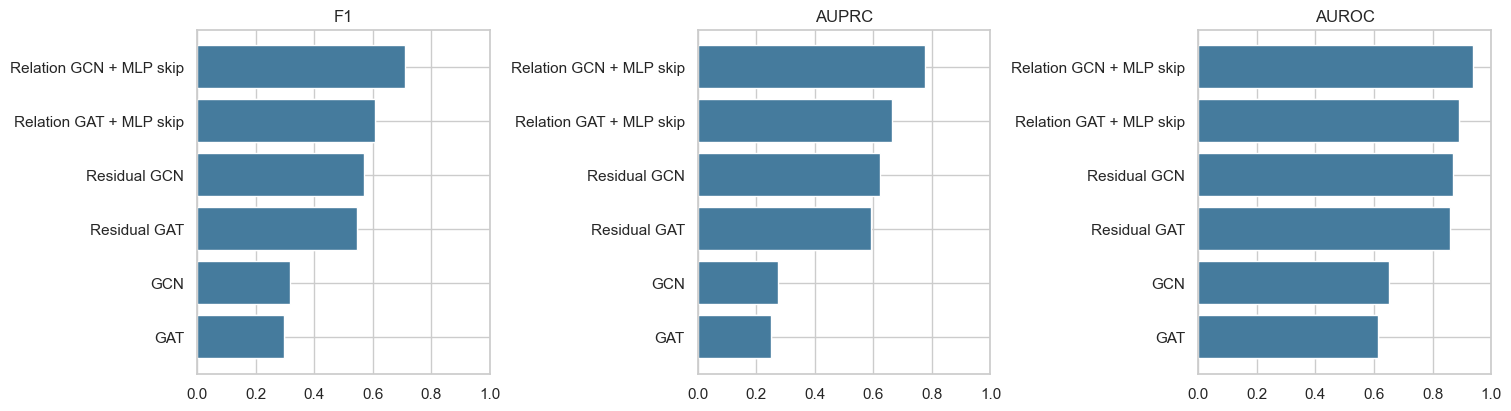

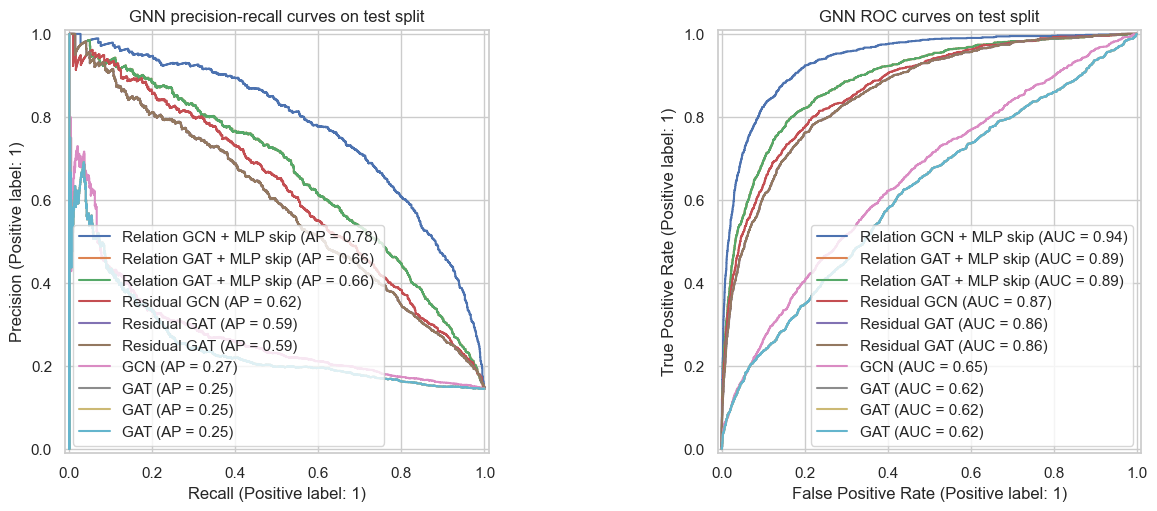

In [102]:
# Analyze only graph neural network rows; MLP is kept as a neural feature-only reference elsewhere.
if "gnn_rows" not in globals() or not gnn_rows:
    raise RuntimeError("Run the GCN/GAT training cells before this analysis cell.")
if "gnn_scores" not in globals():
    raise RuntimeError("Run the GCN/GAT training cells so score arrays are available for PR/ROC curves.")

gnn_metric_df = pd.DataFrame(gnn_rows).copy()
graph_nn_metric_df = gnn_metric_df[gnn_metric_df["model"].str.contains("GCN|GAT", regex=True)].copy()
if graph_nn_metric_df.empty:
    raise RuntimeError("No GCN/GAT rows were found in gnn_rows.")

graph_nn_metric_df = graph_nn_metric_df.sort_values("average_precision", ascending=False)
ranked_metric_df = graph_nn_metric_df[[
    "model",
    "f1",
    "average_precision",
    "roc_auc",
    "precision",
    "recall",
    "balanced_accuracy",
    "accuracy",
    "threshold",
    "best_epoch",
    "runtime_sec",
]].rename(columns={
    "average_precision": "auprc",
    "roc_auc": "auroc",
})
display(ranked_metric_df)

for metric, label in [("f1", "F1"), ("average_precision", "AUPRC"), ("roc_auc", "AUROC")]:
    best = graph_nn_metric_df.loc[graph_nn_metric_df[metric].idxmax()]
    print(f"Best {label}: {best['model']} = {best[metric]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
metric_specs = [
    ("f1", "F1"),
    ("average_precision", "AUPRC"),
    ("roc_auc", "AUROC"),
]
for ax, (metric, title) in zip(axes, metric_specs):
    plot_df = graph_nn_metric_df.sort_values(metric, ascending=True)
    ax.barh(plot_df["model"], plot_df[metric], color="#457b9d")
    ax.set_title(title)
    ax.set_xlim(0, 1)
plt.show()

curve_models = graph_nn_metric_df["model"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for name in curve_models:
    scores = gnn_scores[name]
    PrecisionRecallDisplay.from_predictions(labels[test_mask], scores[test_mask], name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(labels[test_mask], scores[test_mask], name=name, ax=axes[1])
axes[0].set_title("GNN precision-recall curves on test split")
axes[1].set_title("GNN ROC curves on test split")
plt.show()


## 8. Ising MCEM

This section adapts the Gibbs MCEM Ising model to the same full-data evaluation protocol used above. It uses all YelpChi nodes, the same `combined_adj` graph, the same `features`, and the same `train_mask`, `val_mask`, and `test_mask`.

The training labels are visible only on `train_mask`. The validation and test labels are hidden from the MCEM sampler. For final metrics, the posterior fraud probabilities are passed into the shared `evaluate_scores(...)` helper from Section 6, so the decision threshold is calibrated on `val_mask` and evaluated on `test_mask`, just like the logistic and GNN models.

The model is listed below.

$$
P_{\beta,\gamma}(\sigma\mid X,G) \propto
\exp\left(
\beta \sum_{(i,j)\in E}\sigma_i\sigma_j
+ 2\sum_i \sigma_i X_i^T\gamma
\right),
$$


In [64]:
import time

from scipy.special import expit

# Raw MCEM settings; this cell is safe to edit before running Section 8.3.
ISING_NUM_EM_STEPS = 6
ISING_NUM_BURNIN = 15
ISING_NUM_SAMPLES = 16
ISING_THINNING = 2
ISING_INIT_LOGISTIC_C = 1.0
ISING_LASSO_C = 0.25
ISING_OPTIMIZER_MAXITER = 300
ISING_BETA_NONNEGATIVE = True
ISING_INIT_CLASS_WEIGHT = "balanced"
ISING_MSTEP_CLASS_WEIGHT = "balanced"
ISING_ADD_INTERCEPT = True

print("Ising MCEM full-data configuration")
print(f"EM steps={ISING_NUM_EM_STEPS}, burn-in={ISING_NUM_BURNIN}, samples={ISING_NUM_SAMPLES}, thinning={ISING_THINNING}")


Ising MCEM full-data configuration
EM steps=6, burn-in=15, samples=16, thinning=2


### 8.1 Full-Graph Ising Data

The Ising model uses spin labels: `+1` for fraud/spam and `-1` for legitimate reviews. Labels outside `train_mask` are set to `0`, meaning unknown to the sampler. Feature standardization is fit only on the training nodes to avoid validation/test leakage.


In [65]:
# Spin labels: +1 fraud, -1 legitimate, 0 unknown/hidden.
ising_A = combined_adj.tocsr()
ising_y_spin = np.where(labels == 1, 1, -1).astype(np.int8)
ising_y_observed = np.zeros_like(ising_y_spin, dtype=np.int8)
ising_y_observed[train_mask] = ising_y_spin[train_mask]

# Fit feature scaling only on observed training labels.
ising_feature_scaler = StandardScaler()
ising_X_std = ising_feature_scaler.fit(features[train_mask]).transform(features).astype(np.float32)
if ISING_ADD_INTERCEPT:
    ising_X_model = np.column_stack([
        np.ones(ising_X_std.shape[0], dtype=np.float32),
        ising_X_std,
    ]).astype(np.float32)
    ising_feature_names = ["intercept"] + [f"x_{i:02d}" for i in range(features.shape[1])]
else:
    ising_X_model = ising_X_std
    ising_feature_names = [f"x_{i:02d}" for i in range(features.shape[1])]

# Check that MCEM hides exactly the validation/test labels.
ising_split_summary = pd.DataFrame({
    "split": ["train/observed", "validation/hidden", "test/hidden"],
    "nodes": [train_mask.sum(), val_mask.sum(), test_mask.sum()],
    "fraud_spam": [
        int((labels[train_mask] == 1).sum()),
        int((labels[val_mask] == 1).sum()),
        int((labels[test_mask] == 1).sum()),
    ],
    "legitimate": [
        int((labels[train_mask] == 0).sum()),
        int((labels[val_mask] == 0).sum()),
        int((labels[test_mask] == 0).sum()),
    ],
})

print(f"Ising graph: {ising_A.shape[0]:,} nodes, {ising_A.nnz // 2:,} undirected edges")
print(f"Ising design matrix: {ising_X_model.shape[0]:,} nodes x {ising_X_model.shape[1]:,} features")
display(ising_split_summary)


Ising graph: 45,954 nodes, 3,846,979 undirected edges
Ising design matrix: 45,954 nodes x 33 features


,split,nodes,fraud_spam,legitimate
0,train/observed,27572,4006,23566
1,validation/hidden,9191,1336,7855
2,test/hidden,9191,1335,7856


### 8.2 Gibbs MCEM Implementation

The model combines a node-feature external field with a graph-coupling term. Gibbs sampling fills in the hidden validation/test spins given current parameters, then the M-step fits a logistic pseudo-likelihood over sampled complete spin configurations.


In [ ]:
# Initialize the external field from a supervised logistic model on observed nodes.
def initialize_ising_parameters_via_logistic(
    X,
    y_spin_observed,
    l2_C=1.0,
    max_iter=1_000,
    random_state=RANDOM_STATE,
    class_weight=ISING_INIT_CLASS_WEIGHT,
):
    X = np.asarray(X, dtype=np.float32)
    y_spin_observed = np.asarray(y_spin_observed, dtype=np.int8)
    observed = y_spin_observed != 0
    y_binary = (y_spin_observed[observed] == 1).astype(int)
    if np.unique(y_binary).size < 2:
        raise ValueError("Observed training labels must contain both classes.")

    model = LogisticRegression(
        C=l2_C,
        fit_intercept=False,
        solver="lbfgs",
        max_iter=max_iter,
        random_state=random_state,
        class_weight=class_weight,
    )
    model.fit(X[observed], y_binary)

    logits = model.decision_function(X)
    initial_prob_plus = expit(logits)
    beta0 = 0.0
    gamma0 = model.coef_.reshape(-1).astype(float) / 4.0
    sigma0 = np.where(initial_prob_plus >= 0.5, 1, -1).astype(np.int8)
    sigma0[observed] = y_spin_observed[observed]
    return beta0, gamma0, sigma0, initial_prob_plus, model


# One Gibbs sweep over hidden spins, updating neighbor sums incrementally.
def gibbs_sweep_inplace(sigma, neighbor_sum, unlabeled_idx, A, linear_term, beta, rng):
    order = rng.permutation(unlabeled_idx)
    for i in order:
        h_i = beta * neighbor_sum[i] + linear_term[i]
        p_plus = expit(np.clip(2.0 * h_i, -60.0, 60.0))
        new_val = 1 if rng.random() < p_plus else -1
        old_val = sigma[i]
        if new_val != old_val:
            delta = new_val - old_val
            sigma[i] = new_val
            neighbors = A.indices[A.indptr[i]:A.indptr[i + 1]]
            neighbor_sum[neighbors] += delta
    return sigma, neighbor_sum


# Draw complete spin configurations while clamping observed training labels.
def draw_ising_posterior_samples(
    sigma_start,
    observed_mask,
    y_spin_observed,
    A,
    X,
    beta,
    gamma,
    num_burnin=15,
    num_samples=16,
    thinning=2,
    seed=RANDOM_STATE,
):
    rng = np.random.default_rng(seed)
    sigma = np.asarray(sigma_start, dtype=np.int8).copy()
    sigma[observed_mask] = y_spin_observed[observed_mask]
    unlabeled_idx = np.flatnonzero(~observed_mask)
    neighbor_sum = np.asarray(A @ sigma.astype(float), dtype=np.float64).reshape(-1)
    linear_term = 2.0 * (X @ gamma)
    samples = []

    total_sweeps = num_burnin + num_samples * thinning
    for sweep in range(total_sweeps):
        sigma, neighbor_sum = gibbs_sweep_inplace(
            sigma=sigma,
            neighbor_sum=neighbor_sum,
            unlabeled_idx=unlabeled_idx,
            A=A,
            linear_term=linear_term,
            beta=beta,
            rng=rng,
        )
        sigma[observed_mask] = y_spin_observed[observed_mask]
        after_burnin = sweep + 1 - num_burnin
        if after_burnin > 0 and after_burnin % thinning == 0:
            samples.append(sigma.copy())

    return np.asarray(samples, dtype=np.int8), sigma.copy()


def estimate_ising_posterior_probabilities(samples, observed_mask, y_spin_observed):
    posterior_mean = samples.mean(axis=0).astype(float)
    posterior_mean[observed_mask] = y_spin_observed[observed_mask]
    posterior_prob_plus = 0.5 * (posterior_mean + 1.0)
    return posterior_mean, posterior_prob_plus


# M-step design: neighbor field plus node features for sampled complete labels.
def build_ising_pseudolikelihood_design(samples, A, X):
    samples = np.asarray(samples, dtype=np.int8)
    X = np.asarray(X, dtype=np.float32)
    n_samples, n_nodes = samples.shape
    n_features = X.shape[1]
    design = np.empty((n_samples * n_nodes, n_features + 1), dtype=np.float32)
    target = np.empty(n_samples * n_nodes, dtype=np.int8)

    feature_block = 4.0 * X
    for sample_id, sigma in enumerate(samples):
        start = sample_id * n_nodes
        end = start + n_nodes
        neighbor_sum = np.asarray(A @ sigma.astype(float), dtype=np.float32).reshape(-1)
        design[start:end, 0] = 2.0 * neighbor_sum
        design[start:end, 1:] = feature_block
        target[start:end] = (sigma == 1).astype(np.int8)

    return design, target


def optimize_ising_m_step(
    samples,
    A,
    X,
    lasso_C=1.0,
    beta_nonnegative=True,
    max_iter=300,
    seed=RANDOM_STATE,
    class_weight=ISING_MSTEP_CLASS_WEIGHT,
):
    design, target = build_ising_pseudolikelihood_design(samples, A, X)
    model = LogisticRegression(
        C=lasso_C,
        fit_intercept=False,
        solver="saga",
        max_iter=max_iter,
        tol=1e-3,
        random_state=seed,
        class_weight=class_weight,
    )
    model.fit(design, target)
    coef = model.coef_.reshape(-1)
    beta_hat = float(coef[0])
    gamma_hat = coef[1:].astype(float)
    if beta_nonnegative and beta_hat < 0.0:
        beta_hat = 0.0
    return beta_hat, gamma_hat, model


# Alternates Gibbs sampling and pseudo-likelihood M-steps.
def run_ising_mcem(
    y_spin_observed,
    X,
    A,
    num_em_steps=6,
    num_burnin=15,
    num_samples=16,
    thinning=2,
    lasso_C=0.25,
    init_logistic_C=1.0,
    init_class_weight=ISING_INIT_CLASS_WEIGHT,
    mstep_class_weight=ISING_MSTEP_CLASS_WEIGHT,
    beta_nonnegative=True,
    optimizer_maxiter=300,
    seed=RANDOM_STATE,
):
    y_spin_observed = np.asarray(y_spin_observed, dtype=np.int8)
    X = np.asarray(X, dtype=np.float32)
    observed_mask = y_spin_observed != 0
    unlabeled_mask = ~observed_mask

    beta, gamma, sigma_current, init_prob_plus, init_model = initialize_ising_parameters_via_logistic(
        X=X,
        y_spin_observed=y_spin_observed,
        l2_C=init_logistic_C,
        random_state=seed,
        class_weight=init_class_weight,
    )

    history = []
    posterior_mean = sigma_current.astype(float)
    posterior_prob_plus = 0.5 * (posterior_mean + 1.0)
    sigma_last = sigma_current.copy()

    for step in range(num_em_steps):
        samples, sigma_last = draw_ising_posterior_samples(
            sigma_start=sigma_current,
            observed_mask=observed_mask,
            y_spin_observed=y_spin_observed,
            A=A,
            X=X,
            beta=beta,
            gamma=gamma,
            num_burnin=num_burnin,
            num_samples=num_samples,
            thinning=thinning,
            seed=seed + 1_000 * (step + 1),
        )
        posterior_mean, posterior_prob_plus = estimate_ising_posterior_probabilities(samples, observed_mask, y_spin_observed)
        beta_new, gamma_new, m_step_model = optimize_ising_m_step(
            samples=samples,
            A=A,
            X=X,
            lasso_C=lasso_C,
            beta_nonnegative=beta_nonnegative,
            max_iter=optimizer_maxiter,
            seed=seed + 2_000 * (step + 1),
            class_weight=mstep_class_weight,
        )

        sigma_current = np.where(posterior_mean >= 0.0, 1, -1).astype(np.int8)
        sigma_current[observed_mask] = y_spin_observed[observed_mask]
        m_step_iter = int(np.max(m_step_model.n_iter_))
        history.append({
            "iteration": step + 1,
            "beta": beta_new,
            "gamma_l2_norm": float(np.linalg.norm(gamma_new)),
            "m_step_iterations": m_step_iter,
            "m_step_converged": bool(m_step_iter < optimizer_maxiter),
            "mean_posterior_prob_hidden": float(posterior_prob_plus[unlabeled_mask].mean()),
        })
        print(
            f"EM {step + 1}/{num_em_steps}: beta={beta_new:.4f}, "
            f"||gamma||={np.linalg.norm(gamma_new):.4f}, m-step iter={m_step_iter}"
        )
        beta, gamma = beta_new, gamma_new

    return {
        "beta": beta,
        "gamma": gamma,
        "posterior_mean": posterior_mean,
        "posterior_prob_plus": posterior_prob_plus,
        "observed_mask": observed_mask,
        "unlabeled_mask": unlabeled_mask,
        "history": history,
        "initial_logistic_prob_plus": init_prob_plus,
        "initial_logistic_model": init_model,
        "last_complete_state": sigma_last,
    }


### 8.3 Fit Full-Graph Ising MCEM

This cell is the expensive part. It samples hidden validation/test labels while keeping training labels fixed, then updates the Ising graph coupling and feature-field coefficients. The output score is the posterior probability that each node has spin `+1`, i.e. fraud/spam.


In [ ]:
# Expensive cell: run only when you want the raw MCEM baseline.
ising_start_time = time.perf_counter()
ising_results = run_ising_mcem(
    y_spin_observed=ising_y_observed,
    X=ising_X_model,
    A=ising_A,
    num_em_steps=ISING_NUM_EM_STEPS,
    num_burnin=ISING_NUM_BURNIN,
    num_samples=ISING_NUM_SAMPLES,
    thinning=ISING_THINNING,
    lasso_C=ISING_LASSO_C,
    init_logistic_C=ISING_INIT_LOGISTIC_C,
    init_class_weight=ISING_INIT_CLASS_WEIGHT,
    mstep_class_weight=ISING_MSTEP_CLASS_WEIGHT,
    beta_nonnegative=ISING_BETA_NONNEGATIVE,
    optimizer_maxiter=ISING_OPTIMIZER_MAXITER,
    seed=RANDOM_STATE,
)
ising_runtime_sec = time.perf_counter() - ising_start_time
print(f"Ising MCEM runtime: {ising_runtime_sec:.2f} seconds")


c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


EM 1/6: beta=0.0012, ||gamma||=0.4203, m-step iter=25


c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


EM 2/6: beta=0.0017, ||gamma||=0.2903, m-step iter=26


c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


EM 3/6: beta=0.0019, ||gamma||=0.2662, m-step iter=24


c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\20TBa\.conda\envs\btctran\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


### 8.4 Fair Evaluation And Comparison

The main Ising row below uses the same validation-threshold calibration as every other row in the textbook. No 0.5 decision threshold is used for the final comparison.


,model,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,accuracy,runtime_sec
0,Ising MCEM posterior,0.63,0.736486,0.325401,0.4,0.342021,0.481648,0.662094,0.790121,233.751316


,model,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,accuracy,best_epoch,runtime_sec
9,Relation GCN + MLP skip,0.740402,0.939147,0.776652,0.708908,0.705490,0.712360,0.830912,0.915026,198.0,63.030969
12,Relation GAT + MLP skip,0.740000,0.889562,0.661613,0.607498,0.620797,0.594757,0.766510,0.888369,155.0,81.634615
4,Feature + graph-stat logistic regression,0.739294,0.905941,0.669197,0.599857,0.574366,0.627715,0.774334,0.878359,NaN,NaN
8,Residual GCN,0.705217,0.870108,0.621479,0.571209,0.587490,0.555805,0.744743,0.878794,195.0,61.770449
6,MLP,0.660000,0.853563,0.576158,0.547183,0.500310,0.603745,0.750638,0.854858,157.0,42.034384
11,Residual GAT,0.710000,0.859119,0.589927,0.546757,0.524038,0.571536,0.741661,0.862365,200.0,147.460992
5,Feature smoothing logistic regression,0.606380,0.780190,0.409377,0.433914,0.350554,0.569288,0.695031,0.784245,NaN,NaN
1,Feature logistic regression,0.635524,0.772243,0.398334,0.411510,0.350554,0.498127,0.670652,0.793058,NaN,NaN
13,Ising MCEM posterior,0.630000,0.736486,0.325401,0.400000,0.342021,0.481648,0.662094,0.790121,NaN,233.751316
3,Graph label propagation,0.160000,0.649902,0.279658,0.318398,0.239098,0.476404,0.609384,0.703732,NaN,NaN


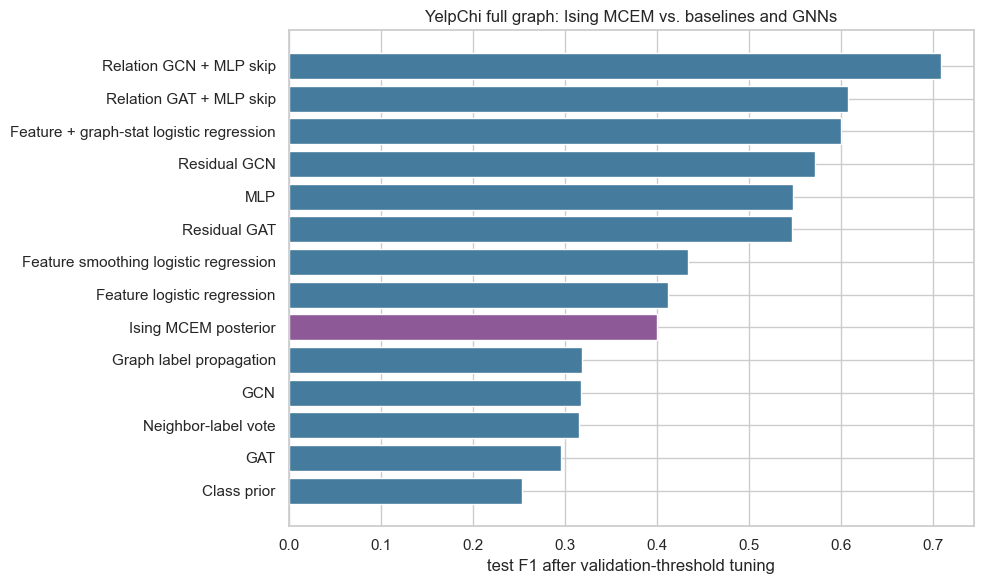

In [100]:
# Main row uses evaluate_scores(), so threshold is calibrated on val_mask.
ising_scores = {
    "Ising MCEM posterior": ising_results["posterior_prob_plus"],
}
ising_row = evaluate_scores("Ising MCEM posterior", ising_scores["Ising MCEM posterior"])
ising_row["runtime_sec"] = ising_runtime_sec
ising_results_df = pd.DataFrame([ising_row])
display(ising_results_df)

# Merge whatever baselines/GNNs have already been run in this kernel.
method_rows = {}
if "baseline_results" in globals():
    for row in baseline_results:
        method_rows[row["model"]] = row
if "gnn_rows" in globals():
    for row in gnn_rows:
        method_rows[row["model"]] = row
method_rows[ising_row["model"]] = ising_row

all_full_graph_results_df = pd.DataFrame(method_rows.values()).sort_values("f1", ascending=False)
display(all_full_graph_results_df)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = all_full_graph_results_df.sort_values("f1", ascending=True)
colors = ["#8d5a97" if name == "Ising MCEM posterior" else "#457b9d" for name in plot_df["model"]]
ax.barh(plot_df["model"], plot_df["f1"], color=colors)
ax.set_xlabel("test F1 after validation-threshold tuning")
ax.set_title("YelpChi full graph: Ising MCEM vs. baselines and GNNs")
plt.tight_layout()
plt.show()


### 8.5 Ising Diagnostics

The EM history is useful for checking whether the graph coupling `beta` and feature-field norm stabilize. If the M-step repeatedly hits `ISING_OPTIMIZER_MAXITER`, increase the optimizer limit or loosen the solver tolerance.


,iteration,beta,gamma_l2_norm,m_step_iterations,m_step_converged,mean_posterior_prob_hidden
0,1,0.001187,0.420218,25,True,0.422853
1,2,0.001691,0.290264,26,True,0.458900
2,3,0.001908,0.266168,24,True,0.466394
3,4,0.002037,0.261520,24,True,0.470045
4,5,0.002083,0.262078,27,True,0.471681
5,6,0.002071,0.260927,26,True,0.471990
6,7,0.002111,0.260216,27,True,0.472062
7,8,0.002090,0.261205,26,True,0.471283
8,9,0.002103,0.259760,24,True,0.472075
9,10,0.002089,0.257520,24,True,0.472201


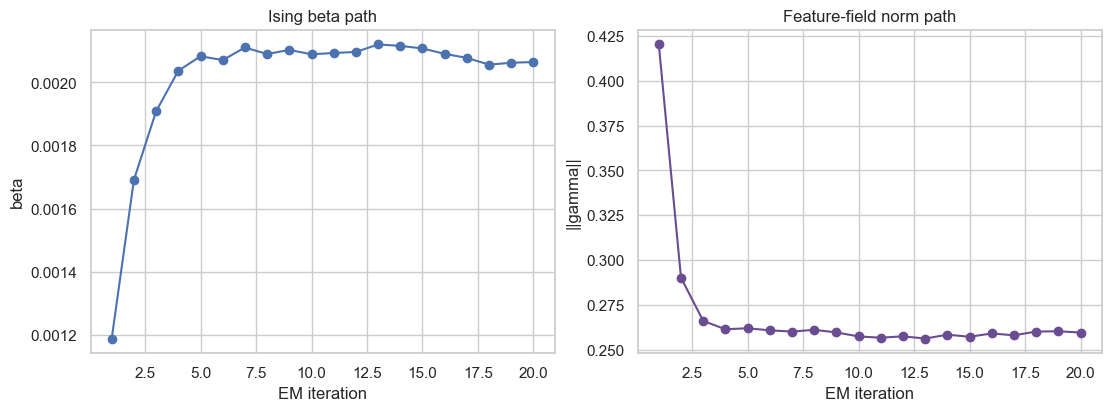

In [101]:
# Plot raw MCEM convergence diagnostics after Section 8.3 runs.
ising_history_df = pd.DataFrame(ising_results["history"])
display(ising_history_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(ising_history_df["iteration"], ising_history_df["beta"], marker="o")
axes[0].set_title("Ising beta path")
axes[0].set_xlabel("EM iteration")
axes[0].set_ylabel("beta")

axes[1].plot(ising_history_df["iteration"], ising_history_df["gamma_l2_norm"], marker="o", color="#6a4c93")
axes[1].set_title("Feature-field norm path")
axes[1].set_xlabel("EM iteration")
axes[1].set_ylabel("||gamma||")
plt.show()
